This is based on the Skeleton.ipynb Notebook
check:


https://bitbucket.imp.ac.at/users/ulises.rey/repos/skeleton/browse

### ReadME -IMPORTANT!
The code in this notebook has been transfered to single python files when possible.

Most of the code here is outdated or experimental. If a python file exists (ometiff2tiff.py) use that one instead of running the cell here.

Check make_skeleton_cluster to run the make_skeleton_function on batch.


# Instructions
Read the Readme.md File

In [2]:
#import pckgs/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/binary_all/lib.pyplot as plt
import pandas as pd
import csv 

import os
import re
import glob
from natsort import natsorted

import tifffile as tiff

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack

In [3]:
from centerline.src.make_skeleton import *

In [4]:
from imutils.src import imfunctions

In [ ]:
## Pipeline
#Extract wrong centerlines test (not all will be from coiled shapes, but the majority)
#Manually segment the coiled worm shapes on Fiji and save them.
#run again make_skeleton, this time on the manually segmented images, use the wrong_centerlines list

In [ ]:
    try: os.mkdir(output_path) # creates the subdirectory where it should be stored
    except: print('Output Directory already exists, might overwrite')

In [5]:
#Extract wrong centerlines test (not all will be from coiled shapes, but the majority)

In [6]:
centerline_csv='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-06-30_17-47-20_chemotaxis_worm4_spline_K.csv'
wrong_centerlines=generate_list_of_wrong_centerlines(centerline_csv)

In [7]:
wrong_centerlines

[3551,
 3552,
 3553,
 3554,
 3555,
 3556,
 3557,
 3558,
 3560,
 3561,
 3562,
 3563,
 3564,
 3565,
 3566,
 3567,
 3568,
 3569,
 3571,
 3968,
 3971,
 3972,
 3973,
 3983,
 4014,
 4018,
 4019,
 4020,
 4021,
 4023,
 4025,
 4026,
 4027,
 4028,
 4029,
 4030,
 4031,
 4032,
 4033,
 4034,
 4035,
 4036,
 4037,
 4038,
 4039,
 4040,
 4041,
 4042,
 4043,
 4044,
 4045,
 4046,
 4047,
 4048,
 4049,
 4050,
 4051,
 4052,
 4053,
 4054,
 4055,
 4056,
 4057,
 4058,
 4059,
 4060,
 4061,
 4062,
 4063,
 4064,
 4065,
 4066,
 4067,
 4068,
 4069,
 4070,
 4071,
 4072,
 4073,
 4074,
 4075,
 4076,
 4077,
 4078,
 4079,
 4080,
 4081,
 4082,
 4083,
 4084,
 4085,
 4086,
 4087,
 4088,
 4089,
 4090,
 4091,
 4092,
 4093,
 4094,
 4095,
 4096,
 4097,
 4098,
 4099,
 4100,
 4101,
 4102,
 4103,
 4104,
 4105,
 4106,
 4107,
 4108,
 4109,
 4110,
 4111,
 4112,
 4113,
 4114,
 4115,
 4116,
 4117,
 4118,
 4119,
 4120,
 4121,
 4122,
 4123,
 4124,
 4125,
 4126,
 4127,
 4128,
 4129,
 4130,
 4131,
 4132,
 4133,
 4134,
 4135,
 4136,
 4137,

In [11]:
input_image='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/binary_all/2020-06-30_17-47-20_chemotaxis_worm4-channel-0-binary.tiff'
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/2020-06-30_17-47-20_chemotaxis_worm4-channel-0-binary'


In [12]:
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/test2'


In [13]:
imfunctions.extract_frames(input_image, output_path, wrong_centerlines)

making  /groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/test2  directory


In [14]:
len_max_number=6
imfunctions.add_zeros_to_filename(output_path, len_max_number)

In [16]:
stack_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/stack.tif'
imfunctions.images2stack(output_path, stack_path)

In [19]:
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/segmented/'
imfunctions.stack2images(stack_path, path)

Output Directory already exists, might overwrite


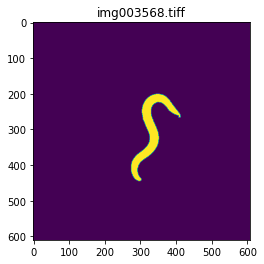

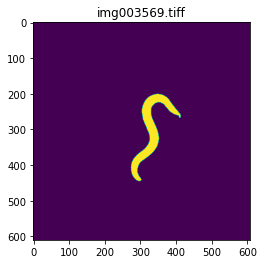

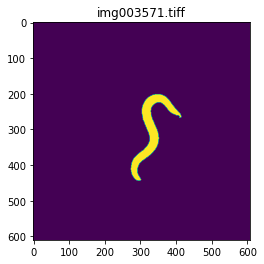

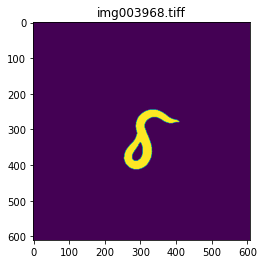

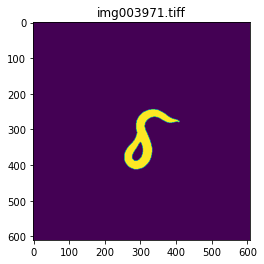

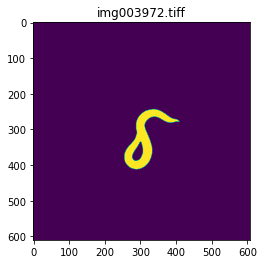

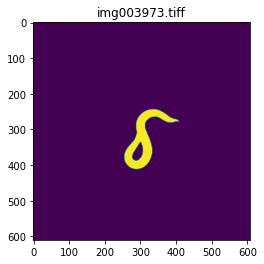

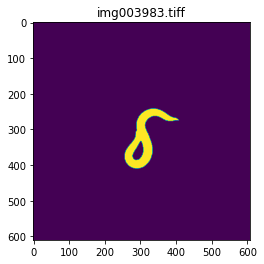

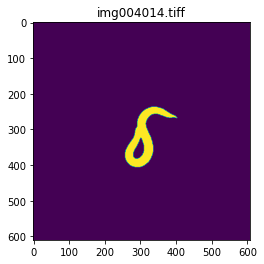

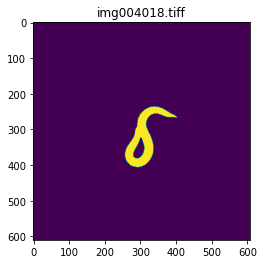

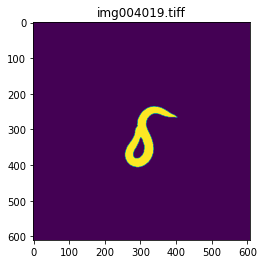

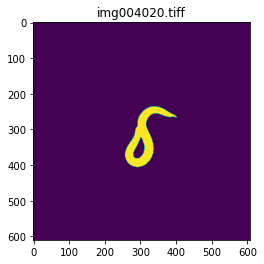

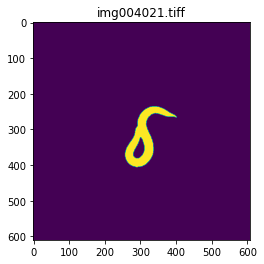

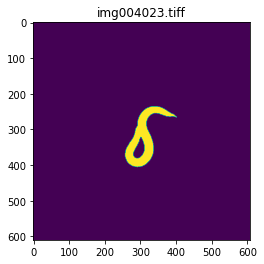

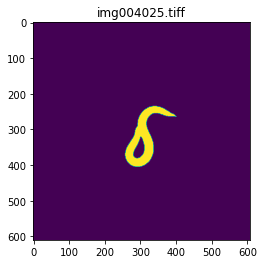

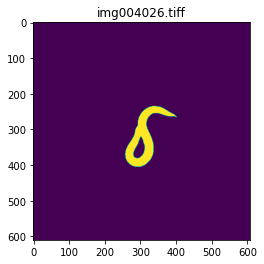

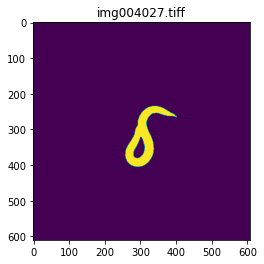

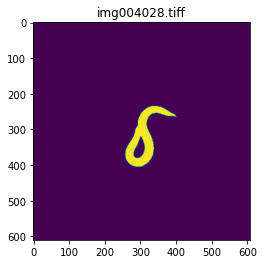

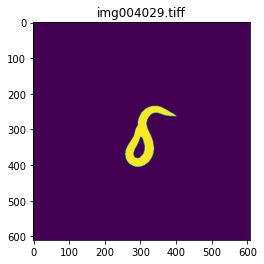

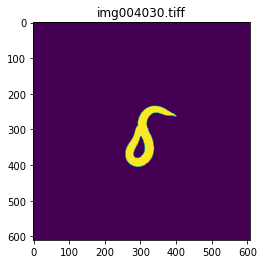

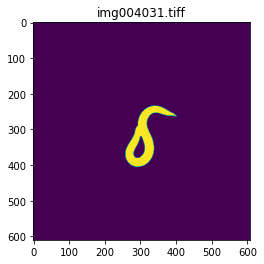

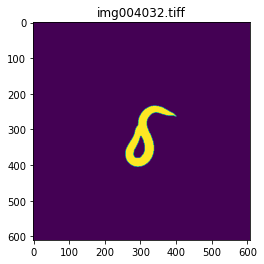

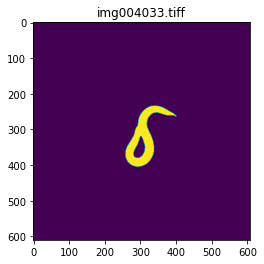

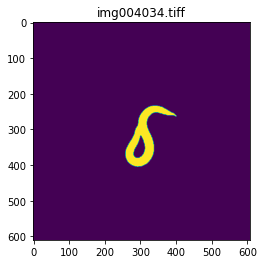

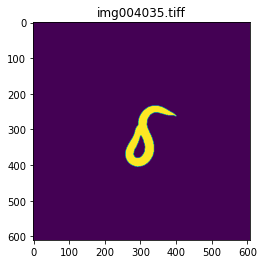

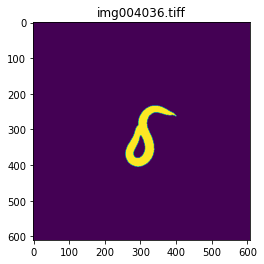

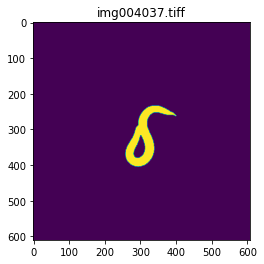

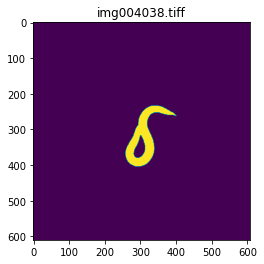

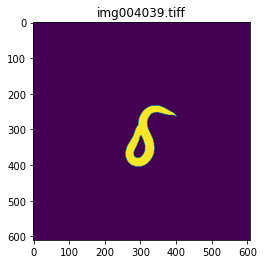

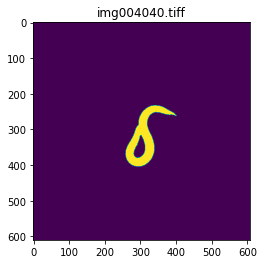

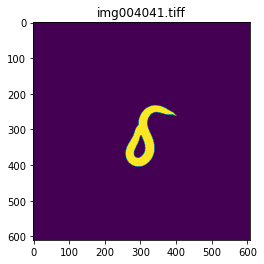

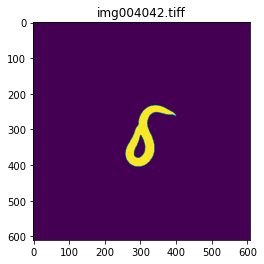

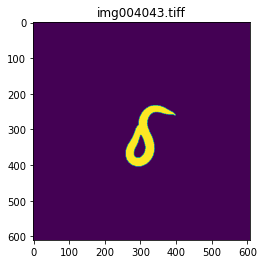

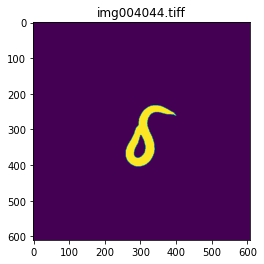

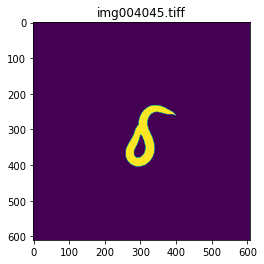

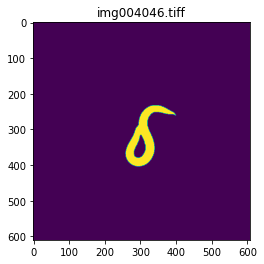

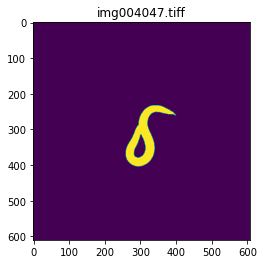

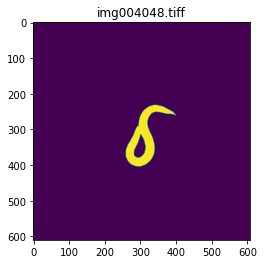

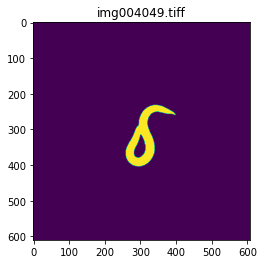

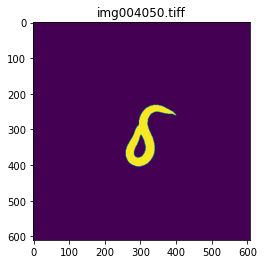

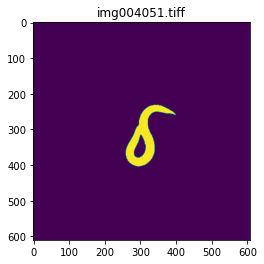

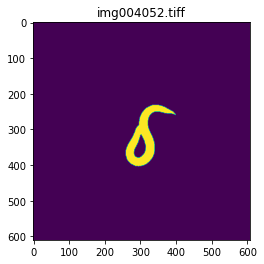

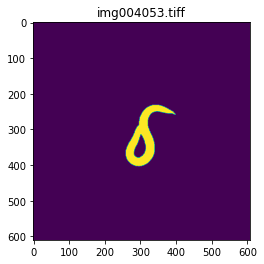

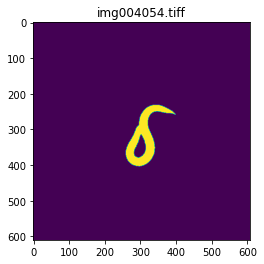

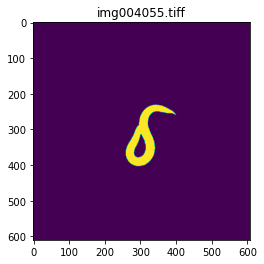

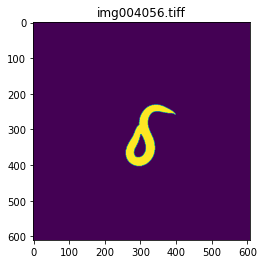

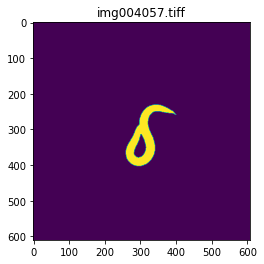

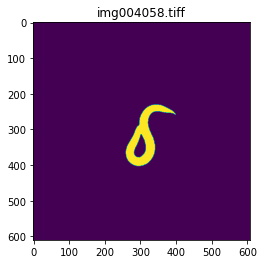

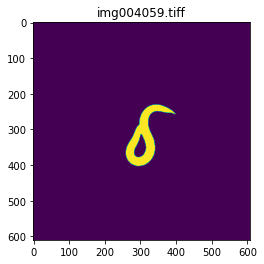

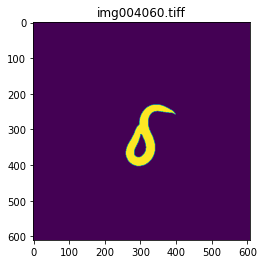

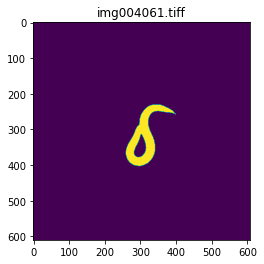

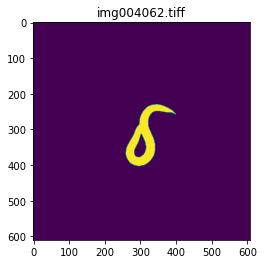

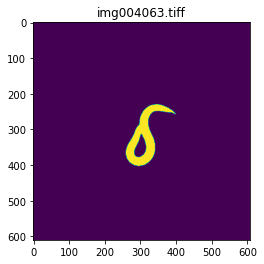

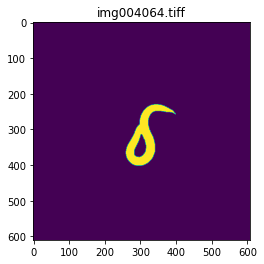

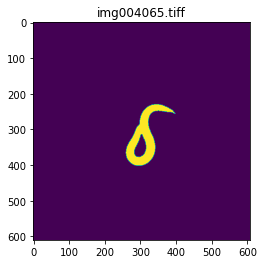

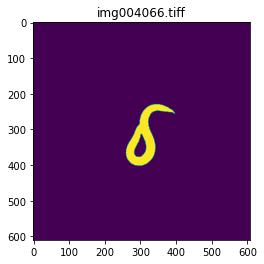

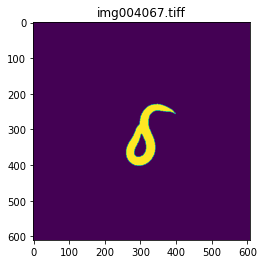

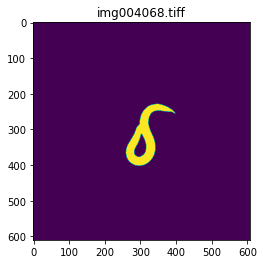

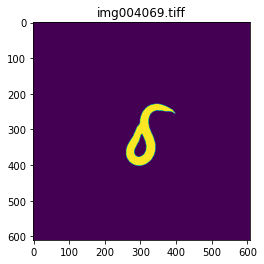

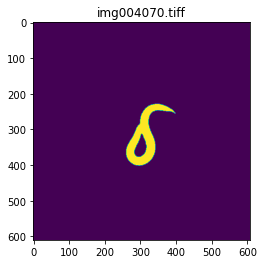

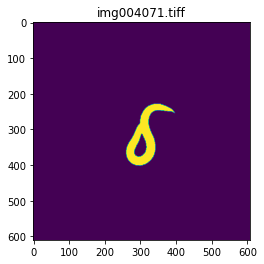

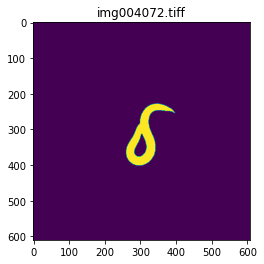

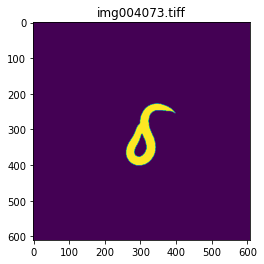

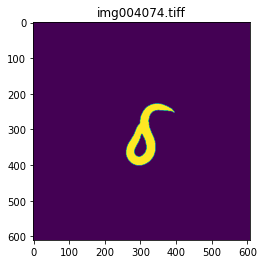

In [44]:
input_filename='Stack_NEW.tif'
with tiff.TiffFile(input_filename) as tif:
    files = tif.imagej_metadata['Info'].split('\n')
    for idx,page in enumerate(tif.pages):
        img=page.asarray()
        plt.imshow(img)
        plt.title(files[idx])
        plt.show()

In [ ]:
#Manually segment the coiled worm shapes on Fiji and save them.
#Recommended pencil tool with Pencil width (pixels)==2, (and color==0)
#Favor the segmentation where the head is more accurate.

In [10]:
# read the stack and metadata
with tiff.TiffFile('imagej.tif') as tif:
    files = tif.imagej_metadata['Info'].split('\n')
    image = tif.asarray()

#define path where to save the segmented images
path='segmented2'
os.mkdir(path)
    
for i, fname in enumerate(files):
    tiff.imsave(os.path.join(path, fname), image[i])

In [69]:
os.path.join(path, fname+'_segmented.tif')

'segmented/img003568.tiff_segmented.tif'

In [ ]:
#run again make_skeleton, this time on the manually segmented images, use the wrong_centerlines list

In [9]:
# #create csv objects
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/'
h5_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_hdf5_filtered/2020-06-30_17-47-20_chemotaxis_worm4-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000.h5'
segmented_stack_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/2020-06-30_17-47-20_chemotaxis_worm4_segmented.tif'

num_splines=100
min_worm_len=300

csvfilePathX=open(output_path+'_skeleton_X_coords.csv','w', newline='')
csv_writerPathX=csv.writer(csvfilePathX)

csvfilePathY=open(output_path+'_skeleton_Y_coords.csv','w', newline='')
csv_writerPathY=csv.writer(csvfilePathY)

csvfileX=open(output_path+'_spline_X_coords.csv','w', newline='')
csv_writerX=csv.writer(csvfileX)

csvfileY=open(output_path+'_spline_Y_coords.csv','w', newline='')
csv_writerY=csv.writer(csvfileY)

csvfileK=open(output_path+'_spline_K.csv','w', newline='')
csv_writerK=csv.writer(csvfileK)


#creates numberic regular expression
regex_num=re.compile(r'\d+')
#read the hdf5
df = pd.read_hdf(h5_filename)#it could be improved to only read the selected rows (as long as hdf5 is in table format): https://stackoverflow.com/questions/33451926/read-hdf5-file-to-pandas-dataframe-with-conditions
scorer=df.columns.get_level_values(0)[0]


with tiff.TiffFile(segmented_stack_path, multifile=True) as tif:
    files = tif.imagej_metadata['Info'].split('\n')
    for idx, page in enumerate(tif.pages):
        img=page.asarray()
        file=files[idx]
        #print('This is the description:', file,'\n')
        #get the number from the description! (It should have!)
        i=int(regex_num.search(file).group(0))
        #print(i)
        #load the X,Y coordinates of the hdf5 file for that timepoint (number)
        #probably x and y need to be swaped
        head_y = int(df.loc[i][scorer,'Head','x'])
        head_x = int(df.loc[i][scorer,'Head','y'])
        start=(head_y, head_x)

        tail_y = int(df.loc[i][scorer,'Tail','x'])
        tail_x = int(df.loc[i][scorer,'Tail','y'])
        end=(tail_y, tail_x)

#         annotated_img=img.copy()

#         cv2.circle(annotated_img,(head_y, head_x),10, (150,150,150), 2)
#         cv2.circle(annotated_img,(tail_y, tail_x),10, (150,150,150), 2)
#         plt.imshow(annotated_img)
#         plt.show()

        #print(start, end)

        #make skeleton function itself
        u, (x,y), (x_new, y_new), K = make_skeleton(start, end, num_splines, img, min_worm_len)

        csv_writerPathX.writerow(x)
        csv_writerPathY.writerow(y)
        csv_writerX.writerow(x_new)
        csv_writerY.writerow(y_new)
        csv_writerK.writerow(K)
csvfilePathX.close()
csvfilePathY.close()
csvfileX.close()
csvfileY.close()
csvfileK.close()
print('end')

This is the description: img003551.tif 

3551
This is the description: img003552.tif 

3552
This is the description: img003553.tif 

3553
This is the description: img003554.tif 

3554
This is the description: img003555.tif 

3555
This is the description: img003556.tif 

3556
This is the description: img003557.tif 

3557
This is the description: img003558.tif 

3558
This is the description: img003560.tif 

3560
This is the description: img003561.tif 

3561
This is the description: img003562.tif 

3562
This is the description: img003563.tif 

3563
This is the description: img003564.tif 

3564
This is the description: img003565.tif 

3565
This is the description: img003566.tif 

3566
This is the description: img003567.tif 

3567
This is the description: img003568.tif 

3568
This is the description: img003569.tif 

3569
This is the description: img003571.tif 

3571
This is the description: img003968.tif 

3968
This is the description: img003971.tif 

3971
This is the description: img003972

In [19]:
def find_nan_centerlines(centerline_csv):
    """
    Should work on the make_skeleton output or on the image (make_skeleton input?)
    Should use the extract frames function

    -----------
    centerline: centerline csv file

    """
    #declare wrong_centerlines empty list
    wrong_centerlines=[]
    correct_centerlines=[]

    # open file in read mode
    with open(centerline_csv, 'r') as read_obj:
        # pass the file object to reader() to get the reader object
        csv_reader = csv.reader(read_obj)
        # Iterate over each row in the csv using reader object
        for idx, row in enumerate(csv_reader):
            # row variable is a list that represents a row in csv
            row_array=np.asarray(row, dtype=np.float64)
            if True in np.isnan(row_array):
                wrong_centerlines.append(idx)
            else:
                correct_centerlines.append(idx)


    return wrong_centerlines, correct_centerlines

In [21]:
centerline_csv='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/_spline_K.csv'
w_centerlines,c_centerlines=find_nan_centerlines(centerline_csv)

In [24]:
len(c_centerlines), len(w_centerlines)

(74, 1379)

In [32]:
df=pd.read_hdf(h5_filename)
scorer=df.columns.get_level_values(0)[0]

In [68]:
#df.loc[i][scorer,:,'x'].values
(x,y,_)=df.loc[3551][scorer,'Head']

### Disclaimer
the code below is a copy of make_skeleton_cluster.py, only used here for testing purpose:

In [231]:
#argumnents
input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/binary_new/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff_binary_th20.tiff'

h5_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5'

h5_centerline_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_OT_Ulises_20201017Oct17shuffle1_340000_filtered.h5'

num_splines=100

In [232]:
#new output path for DLC training
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/old'

### The code below is to test how to incorporate the centerlines from DLC into the current make_skeleton pipeline

In [1]:
#define functions
def spline_fit(x,y, s, num_splines):
    """Produce new coordinates and Curvature (K) from pts and number of splines"""
    tck, u = splprep([x,y], u=None, s=s, per=0, k=5) 
    u_new = np.linspace(u.min(), u.max(), num_splines)#1000)

    x_new, y_new = splev(u_new, tck, der=0)

    #this returns x'(s), y'(s)
    x_der, y_der = splev(u_new, tck, der=1)
    #to have y'(x):
    der=y_der/x_der

    #this returns x''(s), y''(s)
    x_der2, y_der2 = splev(u_new, tck, der=2)
    #to have y''(x), also called K for Curvature:
    #we need the following equation:
    #ref in: https://en.wikipedia.org/wiki/Curvature#In_terms_of_a_general_parametrization (1st equation)
    K=(x_der*y_der2-y_der*x_der2)/np.sqrt(x_der**2+y_der**2)**3
    return (x_new, y_new), K

In [3]:
#argumnets
input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/binary_new/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff_binary_th20.tiff'

h5_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5'

h5_centerline_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_OT_Ulises_20201017Oct17shuffle1_340000_filtered.h5'

num_splines=100

In [5]:
df_centerline=pd.read_hdf(h5_centerline_path)

In [8]:
x=df_centerline.loc[0]['DLC_resnet50_OT_Ulises_20201017Oct17shuffle1_340000',:,'x'].values
y=df_centerline.loc[0]['DLC_resnet50_OT_Ulises_20201017Oct17shuffle1_340000',:,'y'].values

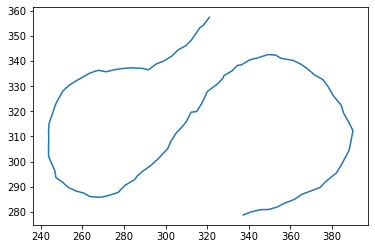

In [9]:
plt.plot(x,y)

In [10]:
#this is the way I found to convert it to tuples..
path=[]
for i,(coordx,coordy) in enumerate(zip(x,y)):
    path.append((coordx,coordy))
    path.append((coordx,coordy))
    path.append((coordx,coordy))

        #print(coord)
    #break
pts=path
pts=np.asarray(path, dtype=np.int)

In [15]:
#to check spline fitting at different timepoints

num_splines=100


t=np.arange(0,12000,25)
for i,tp in enumerate(t):
    fig, axes = plt.subplots(nrows=1, ncols=1, dpi=75, figsize=(7,7))
    fig.subplots_adjust(wspace=0, hspace=0.1)
    
    x=df_centerline.loc[tp]['DLC_resnet50_OT_Ulises_20201017Oct17shuffle1_340000',:,'x'].values
    y=df_centerline.loc[tp]['DLC_resnet50_OT_Ulises_20201017Oct17shuffle1_340000',:,'y'].values
    #print(s)
    tck, u = splprep([x,y], u=None, s=len(x)/2, per=0, k=5) 
    u_new = np.linspace(u.min(), u.max(), num_splines)#1000)

    x_new, y_new = splev(u_new, tck, der=0)
    #axes[i].imshow(annotated_img)
    #axes[i].imshow(skel_img)
    axes.plot(x,y, 'o')
    axes.plot(x_new,y_new,'k', label='frame='+str(tp))
    axes.set_xlim(100, 500)
    axes.set_ylim(100, 500)
    axes.axis('off')
    axes.axis('square')
    #axes.legend('lower left')
    #plt.show()
    fig.savefig('figure/img'+str(i)+'.png')
    plt.close(fig)


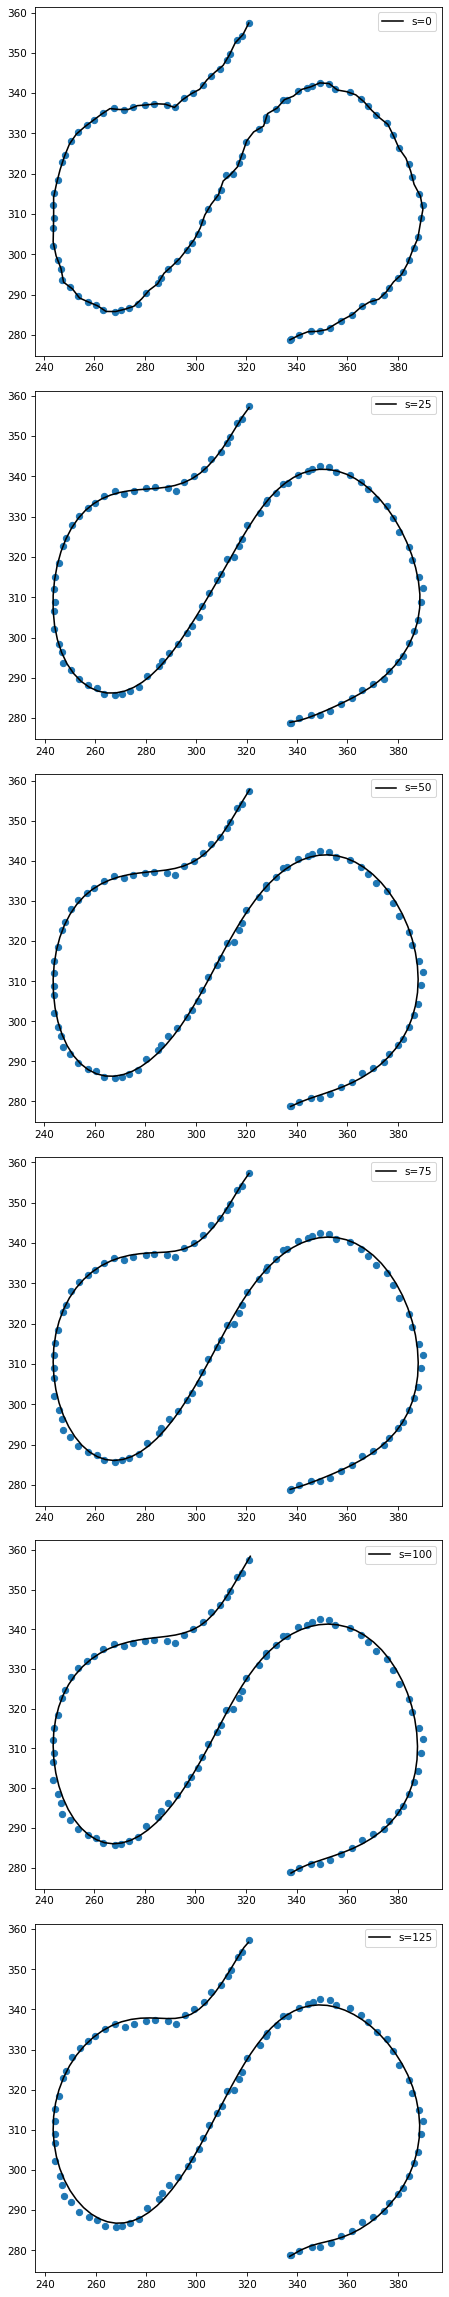

In [213]:
#to check spline fitting at different s values
num_splines=100

#check spline fitting
s_array=np.arange(0,150,25)
fig, axes = plt.subplots(nrows=6, ncols=1, dpi=75, figsize=(7,40))
fig.subplots_adjust(wspace=0, hspace=0.1)


for i,s in enumerate(s_array):
    #print(s)
    tck, u = splprep([x,y], u=None, s=s, per=0, k=5) 
    u_new = np.linspace(u.min(), u.max(), num_splines)#1000)

    x_new, y_new = splev(u_new, tck, der=0)
    #axes[i].imshow(annotated_img)
    #axes[i].imshow(skel_img)
    axes[i].plot(x,y, 'o')
    axes[i].plot(x_new,y_new,'k', label='s='+str(s))
    axes[i].legend()
    #plt.show()


In [7]:
#DONT DELETE: This cell does make a skeleton of the network if the default make_skeleton function fails.
#the source/origin of this code is the make_skeleton_cluster
skel_min_length=300

df = pd.read_hdf(h5_path)
df_centerline=pd.read_hdf(h5_centerline_path)
scorer_centerline=df_centerline.columns.get_level_values(0)[0]


scorer=df.columns.get_level_values(0)[0]
#I do need this still
head_x=df[scorer]['Head']['x'].values
head_y=df[scorer]['Head']['y'].values
tail_x=df[scorer]['Tail']['x'].values
tail_y=df[scorer]['Tail']['y'].values

# #create csv objects
output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/'
#os.mkdir(output_path)
#os.path.join('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_test/',re.split('-channel',re.split('/',input_filename)[-1])[0])

print('\noutput:')
print(output_path)

csvfilePathX=open(output_path+'truenew_skeleton_X_coords.csv','w', newline='')
csv_writerPathX=csv.writer(csvfilePathX)

csvfilePathY=open(output_path+'truenew_skeleton_Y_coords.csv','w', newline='')
csv_writerPathY=csv.writer(csvfilePathY)

csvfileX=open(output_path+'truenew_spline_X_coords.csv','w', newline='')
csv_writerX=csv.writer(csvfileX)

csvfileY=open(output_path+'truenew_spline_Y_coords.csv','w', newline='')
csv_writerY=csv.writer(csvfileY)

csvfileK=open(output_path+'truenew_spline_K.csv','w', newline='')
csv_writerK=csv.writer(csvfileK)




with tiff.TiffFile(input_filename, multifile=False) as tif:
    for i, page in enumerate(tif.pages):
        #if i<3000: continue
        #print(i)
        img=page.asarray()
        
        start_point=(int(head_y[i]), int(head_x[i]))
        end_point = (int(tail_y[i]), int(tail_x[i]))

        #make_skeleton function
        u, skel_coord, spline_coord, K=make_skeleton(start_point, end_point, num_splines, img)
        
        #try if coords can be converted to an array of ints
        try:
            coords=np.asarray(list(zip(*skel_coord)), dtype=int)# the dtype=int makes sures no NaN can be passed, which will cause trouble when indexing
        #exception: get the coords from the centerline hdf5 file
        except:
            #if i%10==0:print('exception')
            #x and y need to be swapped
            y=df_centerline.loc[i][scorer_centerline,:,'x'].values
            x=df_centerline.loc[i][scorer_centerline,:,'y'].values
            skel_coord=np.asarray([x,y], dtype=np.int)
            spline_coord,K=spline_fit(x,y,s=x.shape[0]/2,num_splines=100)
            #I dont know why I have to change the sign
            K=-K
            #print('head and tail were too close, no centerline could be created', c1)
        
        #if there is no exception but the skel is too short, take coords also from centerline 
        else:
            #counter for short skel coords
            if len(skel_coord[0])<=skel_min_length:
                #if i%10==0: print('too short')
                #x and y need to be swapped
                y=df_centerline.loc[i][scorer_centerline,:,'x'].values
                x=df_centerline.loc[i][scorer_centerline,:,'y'].values
#                 skel_coord=[x,y].asarray
                spline_coord,K=spline_fit(x,y,s=x.shape[0]/2,num_splines=100)
                #I dont know why I have to change the sign
                K=-K
        
        #csv writer
#         if i%10==0:
#             plt.subplot(1,2,1)
#             plt.imshow(img)
#             plt.subplot(1,2,2)
#             plt.plot(spline_coord[0], spline_coord[1])
#             plt.title(i)
#             plt.axis('square')
#             plt.show()
        csv_writerPathX.writerow(skel_coord[0])
        csv_writerPathY.writerow(skel_coord[1])
        csv_writerX.writerow(spline_coord[0])
        csv_writerY.writerow(spline_coord[1])
        csv_writerK.writerow(K)
        #if i ==1000:break
csvfilePathX.close()
csvfilePathY.close()
csvfileX.close()
csvfileY.close()
csvfileK.close()
print('end')


output:
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/
end


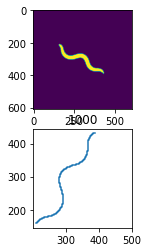

In [35]:
plt.subplot(2,1,1)
plt.imshow(img)
plt.subplot(2,1,2)
plt.plot(skel_coord[0], skel_coord[1])
plt.title(i)
plt.axis('square')
plt.show()

In [ ]:
## end of the code above

## Spline filter Horizontal Kymograph
I want to try to spline filter the kymograph on the Horizontal axis

In [11]:
import csv
csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/2new_spline_K.csv'

# open file in read mode
with open(csv_path, 'r') as read_obj:
    # pass the file object to reader() to get the reader object
    csv_reader = csv.reader(read_obj)
    # Iterate over each row in the csv using reader object
    for row in csv_reader:
        # row variable is a list that represents a row in csv
        plt.plot(float(row))#print(row)
        break

TypeError: float() argument must be a string or a number, not 'list'

In [17]:
csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/2new_spline_K.csv'
df=pd.read_csv(csv_path,header=None)

In [21]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.015593,0.012028,0.006980,0.001881,-0.002539,-0.006172,-0.009224,-0.011992,-0.014777,-0.017854,...,-0.025221,-0.031114,-0.033680,-0.032057,-0.026947,-0.019945,-0.012288,-0.004146,0.005668,0.020591
1,0.059279,0.040853,0.015304,-0.005495,-0.019632,-0.028048,-0.032013,-0.032947,-0.032308,-0.031317,...,-0.030489,-0.035775,-0.036487,-0.032668,-0.026061,-0.018530,-0.010800,-0.001923,0.012214,0.047539
2,0.058213,0.040293,0.015080,-0.005705,-0.019992,-0.028568,-0.032617,-0.033544,-0.032845,-0.031785,...,-0.031000,-0.036014,-0.036351,-0.032224,-0.025462,-0.017876,-0.010045,-0.000755,0.014957,0.057321
3,0.061518,0.041460,0.015090,-0.005977,-0.020371,-0.029129,-0.033388,-0.034449,-0.033761,-0.032610,...,-0.030331,-0.035679,-0.036537,-0.032911,-0.026497,-0.019154,-0.011653,-0.003146,0.010281,0.044382
4,0.059669,0.035599,0.009631,-0.009953,-0.023047,-0.030788,-0.034279,-0.034827,-0.033868,-0.032637,...,-0.030240,-0.035653,-0.036628,-0.033131,-0.026823,-0.019572,-0.012208,-0.004018,0.008500,0.039256
5,0.061355,0.033765,0.007576,-0.011241,-0.023682,-0.031118,-0.034590,-0.035253,-0.034414,-0.033240,...,-0.030633,-0.035881,-0.036700,-0.033102,-0.026747,-0.019478,-0.012110,-0.003956,0.008298,0.037363
6,0.063120,0.035672,0.008813,-0.010813,-0.024088,-0.032253,-0.036166,-0.036893,-0.035810,-0.034229,...,-0.030826,-0.035959,-0.036646,-0.032955,-0.026567,-0.019299,-0.011916,-0.003652,0.009044,0.040082
7,0.063235,0.035956,0.009279,-0.010358,-0.023887,-0.032478,-0.036825,-0.037837,-0.036830,-0.035157,...,-0.030955,-0.036058,-0.036704,-0.032987,-0.026606,-0.019375,-0.012056,-0.003885,0.008695,0.039811
8,0.063138,0.035768,0.009132,-0.010444,-0.023919,-0.032468,-0.036788,-0.037790,-0.036786,-0.035124,...,-0.030991,-0.036110,-0.036758,-0.033027,-0.026627,-0.019384,-0.012062,-0.003904,0.008622,0.039520
9,0.064554,0.035401,0.008231,-0.011197,-0.024251,-0.032306,-0.036219,-0.037000,-0.035967,-0.034404,...,-0.030819,-0.036005,-0.036712,-0.033005,-0.026587,-0.019300,-0.011922,-0.003696,0.008898,0.039651


In [37]:
x=df.loc[:,20].values

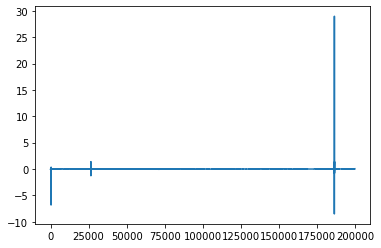

In [38]:
plt.plot(x)

In [60]:
#read csv
#not sure if csv object or pandas is better
#pandas seems to work

# output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/2new'

# csvfileK=open(output_path+'_spline_K.csv','w', newline='')
# csv_writerK=csv.writer(csvfileK)


#process
#spline attempt: does not work
# y=np.arange(len(x))
# tck, u = splprep([x,y], u=None, s=int(len(x)/2), per=0, k=5) 
# u_new = np.linspace(u.min(), u.max(), 200000)
# x_new, y_new = splev(u_new, tck, der=0)

#mean or median averagign also does not work
# avg_win=150
# time=np.arange(25000,27000)
# plt.figure(figsize=(10,10),dpi=200)
# df.loc[time,25].plot()
# df.loc[time,25].rolling(window=avg_win).median().plot()


#I will try an low pass filter: https://medium.com/analytics-vidhya/how-to-filter-noise-with-a-low-pass-filter-python-885223e5e9b7

#write new csv



In [127]:
#anoter attemps with pands
df.rolling(window=5, win_type='gaussian', center=True).mean(std=0.5)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.058667,0.040468,0.015102,-0.005711,-0.019990,-0.028567,-0.032629,-0.033572,-0.032881,-0.031820,...,-0.030873,-0.035951,-0.036385,-0.032345,-0.025637,-0.018082,-0.010298,-0.001136,0.014163,0.054888
3,0.060969,0.040709,0.014506,-0.006373,-0.020616,-0.029246,-0.033401,-0.034393,-0.033675,-0.032525,...,-0.030392,-0.035712,-0.036527,-0.032861,-0.026421,-0.019062,-0.011541,-0.002984,0.010589,0.045213
4,0.060046,0.036029,0.009995,-0.009666,-0.022829,-0.030646,-0.034217,-0.034832,-0.033915,-0.032698,...,-0.030292,-0.035680,-0.036626,-0.033104,-0.026780,-0.019517,-0.012138,-0.003917,0.008670,0.039605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199996,0.035297,-0.001483,-0.013091,-0.020947,-0.028190,-0.034352,-0.037354,-0.035279,-0.028251,-0.018310,...,-0.008498,-0.004938,-0.000492,0.004900,0.011131,0.017717,0.023536,0.026862,0.026195,0.021506
199997,0.013074,-0.005385,-0.014880,-0.022536,-0.029356,-0.034278,-0.035499,-0.032095,-0.024960,-0.016030,...,-0.005684,-0.000457,0.004884,0.009770,0.013538,0.015525,0.015181,0.012059,0.005729,-0.004397
199998,0.027590,0.001026,-0.010976,-0.019477,-0.026728,-0.032240,-0.034407,-0.032094,-0.025823,-0.017365,...,-0.008997,-0.005314,-0.000635,0.005110,0.011789,0.018810,0.024827,0.027875,0.026480,0.021013
199999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


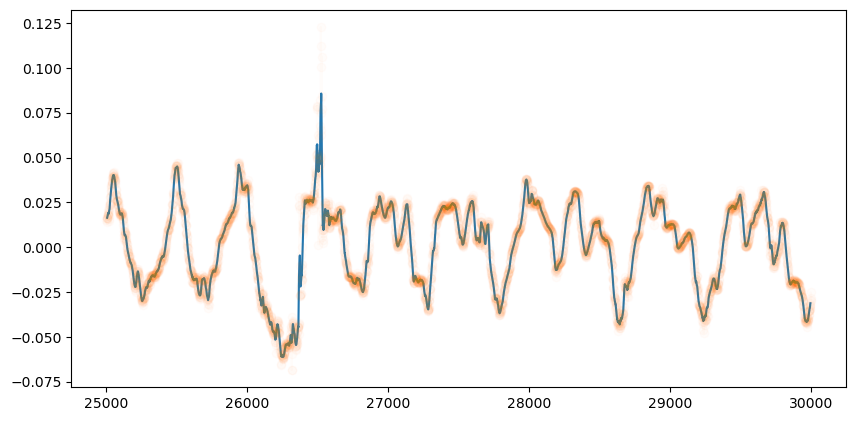

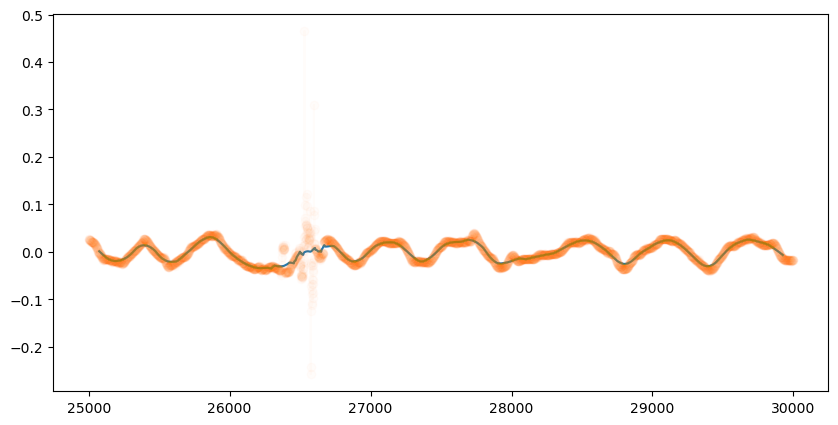

In [166]:
plt.figure(figsize=(10,5), dpi=100)

t=np.arange(25000,30000)
df.loc[t,10].rolling(window=10, win_type='gaussian', center=True).mean(std=25).plot()
df.loc[t,10].plot(marker='o',alpha=.02)

plt.figure(figsize=(10,5), dpi=100)
df.loc[t,25].rolling(window=150, win_type='gaussian', center=True).mean(std=200).plot()
df.loc[t,25].plot(marker='o',alpha=.02)

In [10]:
gdf=df.rolling(window=150, win_type='gaussian', center=True).mean(std=25)

(-0.2, 0.2)

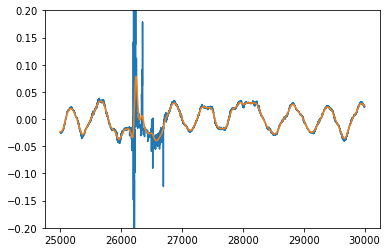

In [14]:
t=np.arange(25000,30000)

df.loc[t,50].plot()
gdf.loc[t,50].plot()
lim=0.2
plt.ylim([-lim,lim])

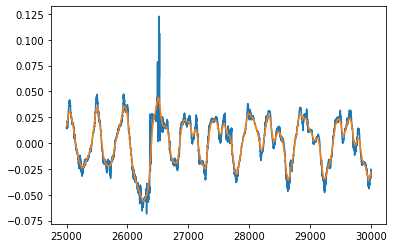

In [11]:
t=np.arange(25000,30000)

df.loc[t,10].plot()
gdf.loc[t,10].plot()


In [15]:

gdf.to_csv('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton_test/2new_spline_K_gaussian.csv')

In [83]:
import numpy as np
from scipy.signal import butter,filtfilt# Filter requirements.
T = 5.0         # Sample Period
fs = 30.0       # sample rate, Hz
cutoff = 2      # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hznyq = 0.5 * fs  # Nyquist Frequencyorder = 2       # sin wave can be approx represented as quadratic
n = int(T * fs) # total number of samples

In [21]:
# sin wave
t=np.arange(100)
sig = np.sin(1.2*2*np.pi*t)# Lets add some noise
noise = 1.5*np.cos(9*2*np.pi*t) + 0.5*np.sin(12.0*2*np.pi*t)
data = sig + noise

In [87]:
def butter_lowpass_filter(data, cutoff, fs, order):
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients 
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

In [91]:
# Filter the data, and plot both the original and filtered signals.
y = butter_lowpass_filter(data, cutoff, fs, order)
fig = go.Figure()
fig.add_trace(go.Scatter(
            y = data,
            line =  dict(shape =  'spline' ),
            name = 'signal with noise'
            ))
fig.add_trace(go.Scatter(
            y = y,
            line =  dict(shape =  'spline' ),
            name = 'filtered signal'
            ))
fig.show()

NameError: name 'order' is not defined

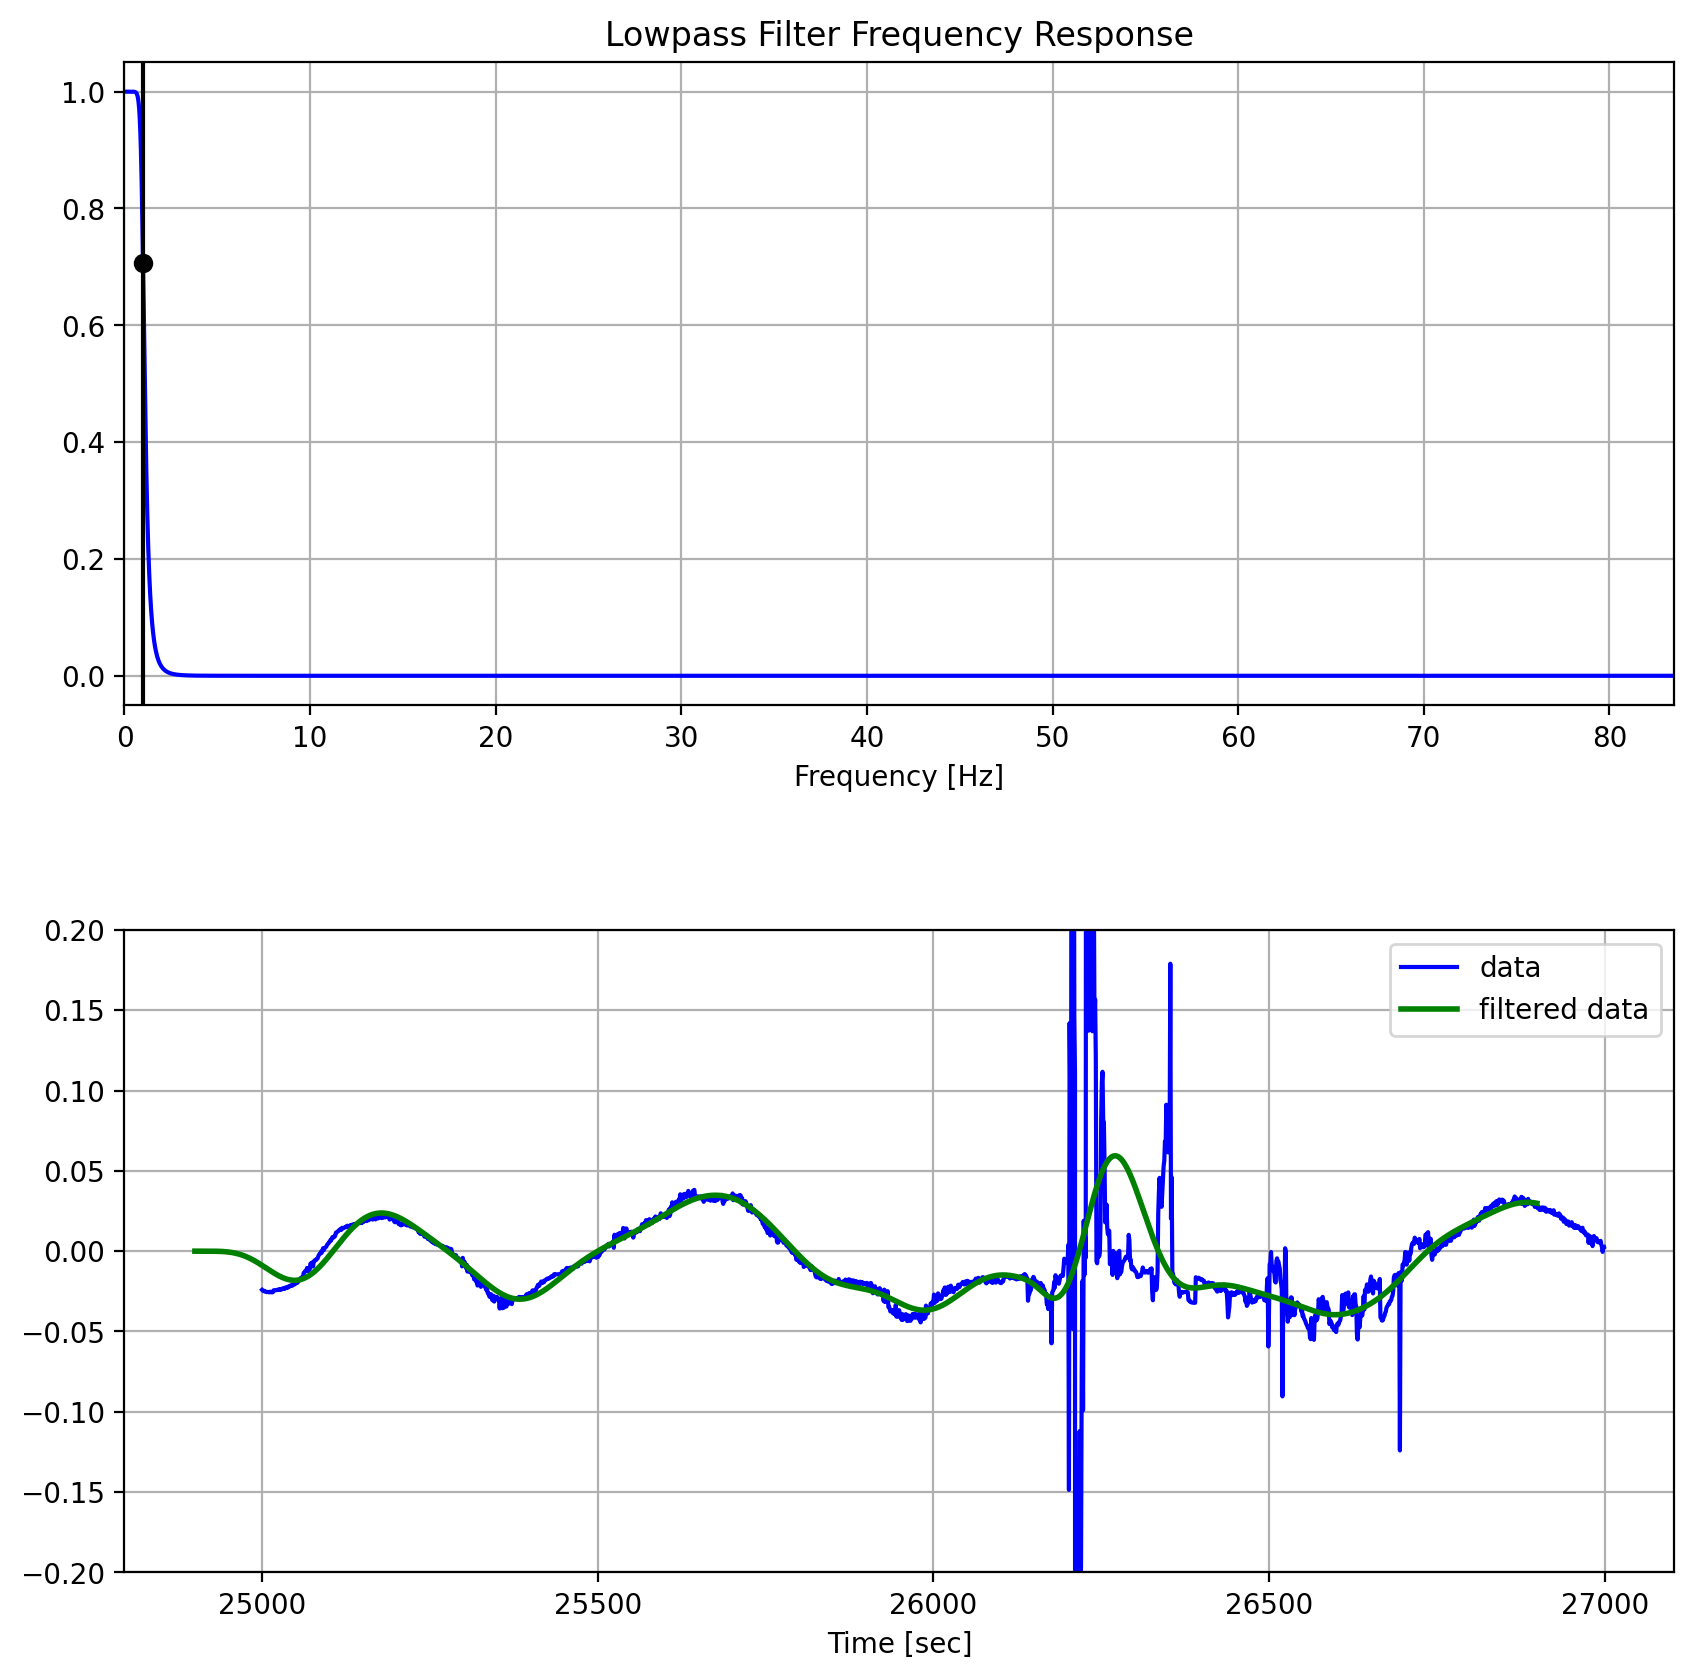

In [19]:
#based on stack overflow (bookmarked)

import numpy as np
from scipy.signal import butter, lfilter, freqz
import matplotlib.pyplot as plt


def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y


# Filter requirements.
order = 6#6
fs = 167.0       # sample rate, Hz
cutoff = 1#3.667  # desired cutoff frequency of the filter, Hz

# Get the filter coefficients so we can check its frequency response.
b, a = butter_lowpass(cutoff, fs, order)

# Plot the frequency response.
w, h = freqz(b, a, worN=8000)
plt.figure(figsize=(10,10), dpi=200)
plt.subplot(2, 1, 1)
plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.plot(cutoff, 0.5*np.sqrt(2), 'ko')
plt.axvline(cutoff, color='k')
plt.xlim(0, 0.5*fs)
plt.title("Lowpass Filter Frequency Response")
plt.xlabel('Frequency [Hz]')
plt.grid()


# Demonstrate the use of the filter.
# First make some data to be filtered.
T = 5.0         # seconds
n = int(T * fs) # total number of samples
t = np.arange(25000,27000)#np.linspace(0, T, n, endpoint=False)
# "Noisy" data.  We want to recover the 1.2 Hz signal from this.
data = df.loc[t,50].values#np.sin(1.2*2*np.pi*t) + 1.5*np.cos(9*2*np.pi*t) + 0.5*np.sin(12.0*2*np.pi*t)

# Filter the data, and plot both the original and filtered signals.
y = butter_lowpass_filter(data, cutoff, fs, order)

plt.subplot(2, 1, 2)
plt.plot(t, data, 'b-', label='data')
tt=t-100
plt.plot(tt, y, 'g-', linewidth=2, label='filtered data')
plt.xlabel('Time [sec]')
plt.ylim(-0.2,0.2)
plt.grid()
plt.legend()

plt.subplots_adjust(hspace=0.35)
plt.show()

In [ ]:
#end of spline filter horizontal

In [49]:

input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_btf/2020-07-01_17-32-12_control_worm4-channel-0-bigtiff.btf2020-07-01_17-32-12_control_worm4-channel-0-TH20_binary.tiff'
bg_img_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/background/2020-07-01_13-42-05_chemotaxisl_worm1_bg-channel-0-_MMStack_Median_BG.tiff'
output_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/2020-07-01_17-32-12_control_worm4-channel-0-TH20_binary.tiff'



bg_img= tiff.imread(bg_img_filename)

with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:
    with tiff.TiffFile(input_filename, multifile=False) as tif:
        #inside_areas=[]
        for i, page in enumerate(tif.pages):
            #if i<48755:continue
            #loads the first frame and inverts it
            img=page.asarray()
            img=cv2.bitwise_not(img)
            
            #substrack background
            img=cv2.subtract(img,bg_img)
            
            #median Blur
            img[:] = cv2.medianBlur(img,5)
            
            #apply threshold
            ret, new_img = cv2.threshold(img,20,255,cv2.THRESH_BINARY)
            #plt.imshow(new_img)
            #plt.show()
            #find contours
            img,contours, hierarchy = cv2.findContours(new_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            #print(len(contours))
            #new_contours = contours[0] if len(contours) == 2 else contours[1]
            
            #list areas of contours, find MAX, draw contours from MAX area
            areas=[]
            for j in range(0, len(contours)):
                areas.append(cv2.contourArea(contours[j]))
            worm_contour=np.where(areas==np.asarray(areas).max())
            worm_contour=np.asarray(worm_contour)
            #print('worm contour:' + str(worm_contour))
            img_contours = np.zeros(img.shape)
            img[:]=cv2.drawContours(img_contours,contours, worm_contour, color=255, thickness=-1, hierarchy=hierarchy, maxLevel=1)
#             plt.figure(dpi=200)
#             plt.imshow(img)
#             plt.show()
            
            #draw inner part empty
            #for every contour (Again)
            for j in range(0, len(contours)):
                #if the contours have as a parent worm_contour
                if hierarchy[0][j][3]==worm_contour:
                    #if the conntours is smaller than 300 sq px, fill it with color 255 (See #18 Labmeeting)
                    #inside_areas.append(cv2.contourArea(contours[j]))
                    
                    #plot a histogram of the inside areas to find the areas you want to discard (this is a function of chosen parameters like threshold)
                    if cv2.contourArea(contours[j])<300:
                        #print(cv2.contourArea(contours[j]))
                        #print('entered')
                        img[:]=cv2.drawContours(img,contours, j, color=255, thickness=-1)
            
            #plt.figure(dpi=200)
            #plt.imshow(img)
            #plt.show()
            #tif_writer.save(img)
            if i ==100000: break
            

In [164]:
for j in range(0, len(contours)):
    areas.append(cv2.contourArea(contours[j]))
worm_contour=np.where(areas==np.asarray(areas).max())

Text(0.5, 1.0, 'Worm Inner Contours size')

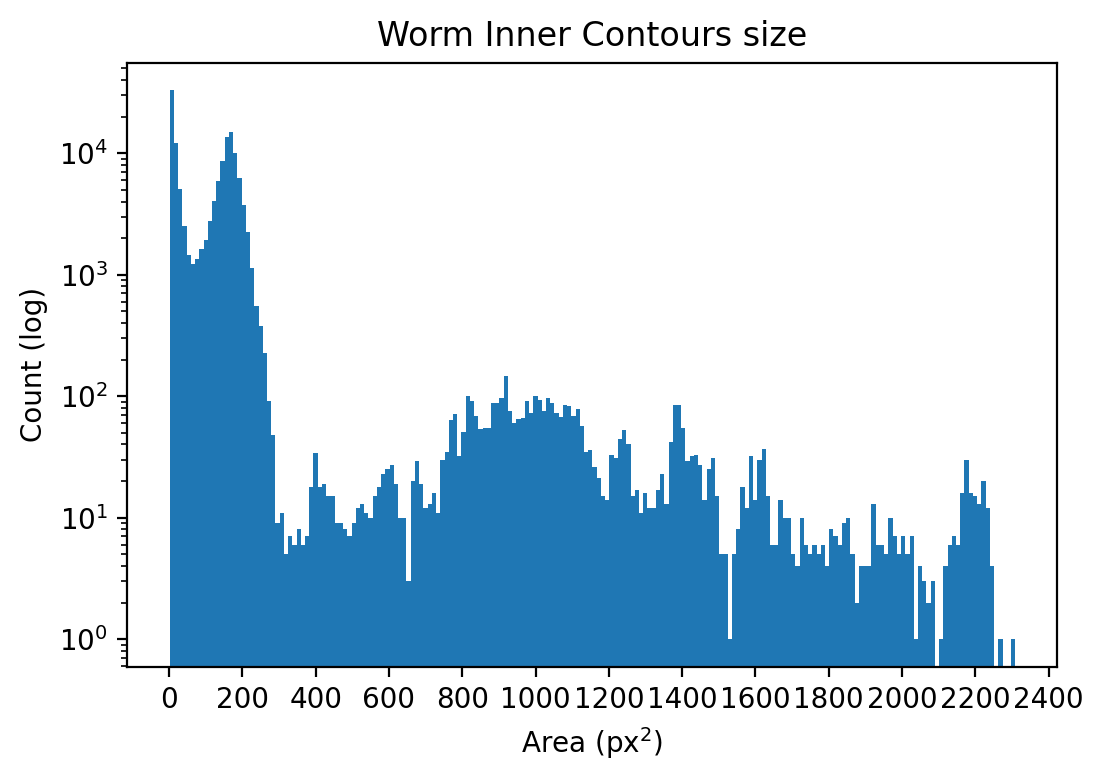

In [56]:
plt.figure(dpi=200)
plt.hist(inside_areas,200, log=True)
plt.ylabel('Count (log)')
plt.xlabel(r'Area (px$^{2}$)')
plt.xticks(np.arange(0,2500, 200))
plt.title('Worm Inner Contours size')

In [60]:
#df.to_csv('/groups/zimmer/Ulises/code/dataframe.csv', index=True)

## Skeleton Test Part

In [3]:
#import functions
def shortest_path2(start,end,binary,costs):
    path, cost = skimage.graph.route_through_array(costs, start=start, end=end, fully_connected=False)
    return path,cost

In [4]:
import pandas as pd

h5_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_hdf5/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000.h5'

df=pd.read_hdf(h5_path)

In [ ]:
df.head(2)

In [23]:
timepoint=28826#211
df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Head']['x']

432.53619384765625

In [5]:
start_point =  (int(299.587006), int(282.180603))
end_point = (int(294.432922), int(373.210541))

In [6]:
start_point =  (int(282.180603), int(299.587006))
end_point = (int(373.210541), int(294.432922))

In [24]:
head_x=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Head']['x']
head_y=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Head']['y']
tail_x=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Tail']['x']
tail_y=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Tail']['y']
start_point =  (int(head_y), int(head_x))
end_point = (int(tail_y), int(tail_x))

In [25]:
print(start_point)
print(end_point)

(192, 432)
(417, 180)


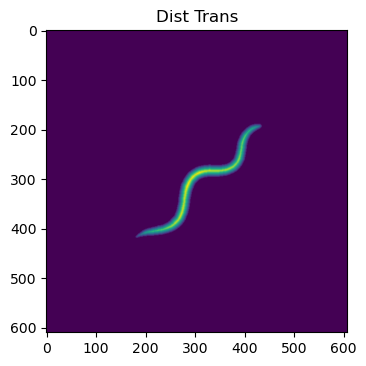

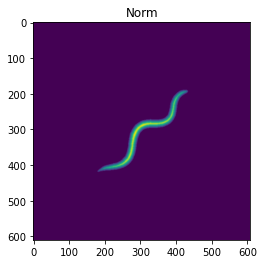

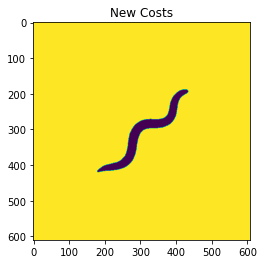

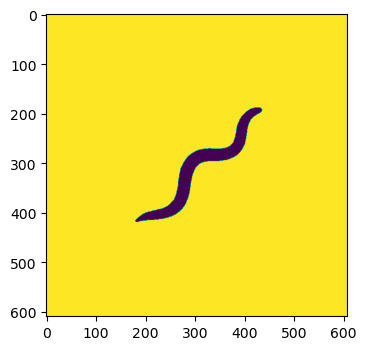

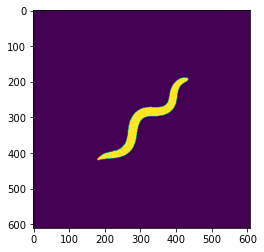

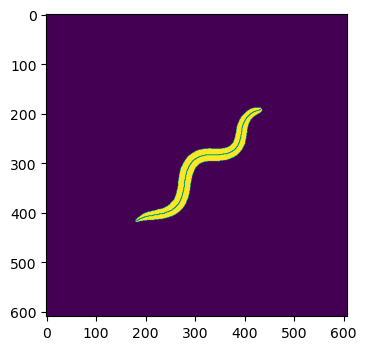

In [27]:
#skeleton part
plt.figure(dpi=100)
#img=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0.tif')
#img=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_manually_segmented.tif')
img=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series1.tif')


#this defines the costs for the shortest path
costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
plt.imshow(costs)
plt.title('Dist Trans')
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_DistTrans.tif',data=costs)

cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
plt.imshow(costs)
plt.title('Norm')
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_DistTrans_Norm.tif',data=costs)

#does an inversion, background now is 255, worm is below 255
costs=costs.max()-costs
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_DistTrans_Norm_AS.tif',data=costs)

#to increase the value a lot of the pixels outside the worm contour (np.inf will not work! sometimes head and tail outside work contour)
costs=np.where(costs==255, 255**2, costs)
#costs=costs**2
plt.imshow(costs)
plt.title('New Costs')
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_New_costs.tif',data=costs)


#costs=np.where(costs==0,np.inf,costs)

plt.figure(dpi=100)
plt.imshow(costs)
plt.show()

path, cost=shortest_path2(start_point, end_point, img, costs)

x,y=np.asarray(list(zip(*path)), dtype=int)
plt.imshow(img)
plt.show()

for x,y in path:
    img[x][y]=20
plt.figure(dpi=100)
plt.imshow(img)
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_Result.tif',data=img)


# OUTDATED >>>>
function below is outdated

TypeError: Invalid shape (10, 1, 2) for image data

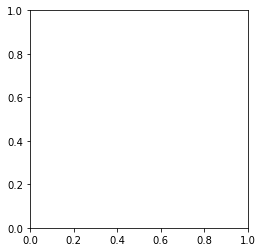

In [77]:
#read and write tiff video for binary

#import pckgs
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv

import os
from natsort import natsorted
import re
import argparse

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

#import functions
def shortest_path2(start,end,binary,costs):
    path, cost = skimage.graph.route_through_array(costs, start=start, end=end, fully_connected=False)
    return path,cost


ap = argparse.ArgumentParser()
ap.add_argument("-i", "--input_filename", required=True, help="path to input file")
ap.add_argument("-h5", "--h5", required=True, help="path to the DLC hdf5 file")

args = vars(ap.parse_args())

input_filename=args['input_filename']
print(input_filename)
print('\n')
h5_path=args['h5']
print(h5_path)
print('\n')

df = pd.read_hdf(h5_path)

scorer=df.columns.get_level_values(0)[0]
head_x=df[scorer]['Head']['x'].values
head_y=df[scorer]['Head']['y'].values
tail_x=df[scorer]['Tail']['x'].values
tail_y=df[scorer]['Tail']['y'].values


# #create csv objects
output_path=os.path.join('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton/',re.split('-channel',re.split('/',input_filename)[-1])[0])
print('\noutput:')
print(output_path)
print('\noutput2:')
print(output_path+'_spline_Y_coords.csv')
csvfilePathX=open(output_path+'_skeleton_X_coords.csv','w', newline='')
csv_writerPathX=csv.writer(csvfilePathX)

csvfilePathY=open(output_path+'_skeleton_Y_coords.csv','w', newline='')
csv_writerPathY=csv.writer(csvfilePathY)

csvfileX=open(output_path+'_spline_X_coords.csv','w', newline='')
csv_writerX=csv.writer(csvfileX)

csvfileY=open(output_path+'_spline_Y_coords.csv','w', newline='')
csv_writerY=csv.writer(csvfileY)

csvfileK=open(output_path+'_spline_K.csv','w', newline='')
csv_writerK=csv.writer(csvfileK)

knots=100

with tiff.TiffFile(input_filename, multifile=False) as tif:
    for i, page in enumerate(tif.pages):
        img=page.asarray()
        #Skeleton approach
        #skeleton = skeletonize(img/255)
        #skeleton=np.asarray(skeleton, dtype="uint8")

        #Scikit graph approach - Shortest Path
        start_point =  (int(head_y[i]), int(head_x[i]))#(286, 124)#
        end_point = (int(tail_y[i]), int(tail_x[i]))#(332,480)#

        #Shortest Path default:
        #path, cost, costs=shortest_path(start_point, end_point, skeleton)

        #Shortest Path 2:
        #I modified the original shortest_path function, now costs are defined outside
        #it works on the img instead of the skeleton, which is then in fact not used

        #this defines the costs for the shortest path
        costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
        cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
        costs=costs.max()-costs  
        
#to increase the value a lot of the pixels outside the worm contour (np.inf will not work! sometimes head and tail outside work contour)
        costs=np.where(costs==255, 255**2, costs)

        path, cost=shortest_path2(start_point, end_point, img, costs)

        x,y=np.asarray(list(zip(*path)), dtype=int)

#         for x,y in path:
#             img[x][y]=0

        pts=np.asarray(path, dtype=np.int)
        #fill K with NaNs if the skeleton is not good
        if len(pts)<knots:
            #print('Knots are Nans in: '+str(i))
            K=np.full(knots, np.nan)
            x=np.full(knots, np.nan)
            y=np.full(knots, np.nan)
            x_new=np.full(knots, np.nan)
            y_new=np.full(knots, np.nan)
        else:
            ####
            #s is the smoothing condition should have around the size of points/2 (keep it low)
            #k is the degree of freedom for the polynom it fits, 5 is good
            #splprep calculates automatically the number of knots. One can see how many in tck.shape[1].
            #everytime splprep is run the number by differ
            tck, u = splprep(pts.T, u=None, s=pts.shape[0]/2, per=0, k=5) 
            u_new = np.linspace(u.min(), u.max(), knots)#1000)

            x_new, y_new = splev(u_new, tck, der=0)

            #this returns x'(s), y'(s)
            x_der, y_der = splev(u_new, tck, der=1)
            #to have y'(x):
            der=y_der/x_der

            #this returns x''(s), y''(s)
            x_der2, y_der2 = splev(u_new, tck, der=2)
            #to have y''(x), also called K for Curvature:
            #we need the following equation:
            #ref in: https://en.wikipedia.org/wiki/Curvature#In_terms_of_a_general_parametrization (1st equation)
            K=(x_der*y_der2-y_der*x_der2)/np.sqrt(x_der**2+y_der**2)**3

        #csv writer
        csv_writerPathX.writerow(x)
        csv_writerPathY.writerow(y)
        csv_writerX.writerow(x_new)
        csv_writerY.writerow(y_new)
        csv_writerK.writerow(K)

        #if i==00:
        #    break
csvfilePathX.close()
csvfilePathY.close()
csvfileX.close()
csvfileY.close()
csvfileK.close()
print('end')

### First generate binary image

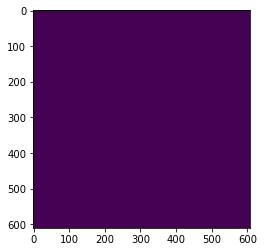

In [6]:
plt.imshow(img)

### Then generate skeleton

I have cleaned this notebook. The code is in the python files. Please use the code in the .py files

## Plottting Derivative

In [ ]:
for frame, k_v in enumerate(all_K):
    x_new=all_x_new[frame]
    y_new=all_y_new[frame]
    der=all_der[frame]
    K=all_K[frame]

    x_cord=np.arange(0,100,1)

    plt.figure(figsize=(20,10))
    r,c=2,2
    # ax1=plt.subplot(r,c,1)
    # plt.plot(x_cord, y_new, 'bo')
    # plt.title('Worm')

    #first der
    ax3=plt.subplot(r,c,1)
    #plt.plot(x_cord,der)
    plt.scatter(x_cord, der, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    ax3.set_ylim(-5, 5)

    plt.axhline(y=0, xmin=0, xmax=1)
    #ax3.set_ylim(-2, 2)
    #ax3.set_xlim(400, 450)
    plt.title('First Derivative')

    ax5=plt.subplot(r,c,2)
    #plt.plot(x_new, der2, 'o')
    plt.scatter(x_cord, K, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#, vmin=-5000, vmax=5000)#y_der2, marker='.', cmap='bwr')
    ax5.set_ylim(-0.1, 0.1)

    plt.axhline(y=0, xmin=0, xmax=1)
    plt.title('Second Derivative')

    #worm first der
    ax2=plt.subplot(r,c,3)
    sc=plt.scatter(x_new, y_new, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    #plt.colorbar(sc)
    plt.title('Color coded worm from First Derivative')



    ax4=plt.subplot(r,c,4)
    sc=plt.scatter(x_new, y_new, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#y_der2, marker='.', cmap='bwr')
    #plt.colorbar(sc)
    plt.title('Color coded worm from Second Derivative')
    plt.savefig('derivatives/'+str(frame)+'.tiff')
    plt.close()

# Plot Kymograph

In [1]:
df=pd.read_csv('/groups/zimmer/Ulises/code/skeleton_outputs/second_der_np_new.csv', header=None)
print(df.shape)
df.head(5)
tdf=df[:1500].transpose()
print(tdf.shape)

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111)
ax.imshow(tdf, vmin=-0.05, vmax=0.05, cmap='bwr')
ax.can_pan=True

#ax.applyaspect()

NameError: name 'pd' is not defined

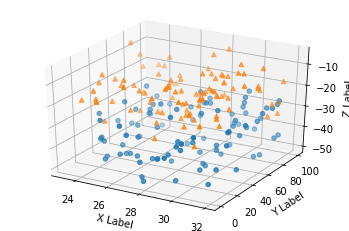

In [17]:
#3D plotting
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)


def randrange(n, vmin, vmax):
    '''
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    '''
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, marker=m)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [ ]:

# Import pandas as pd
import pandas as pd

# Read in the CSV file: df
df=principalDf

# Import figure from bokeh.plotting
from bokeh.plotting import figure
from bokeh.io import push_notebook, show, output_notebook 

# Create the figure: p
p = figure(x_axis_label='PC2', y_axis_label='PC3')

# Plot mpg vs hp by color
p.circle(df['PC2'], df['PC3'], size=10)

# Specify the name of the output file and show the result
output_notebook()
show(p)

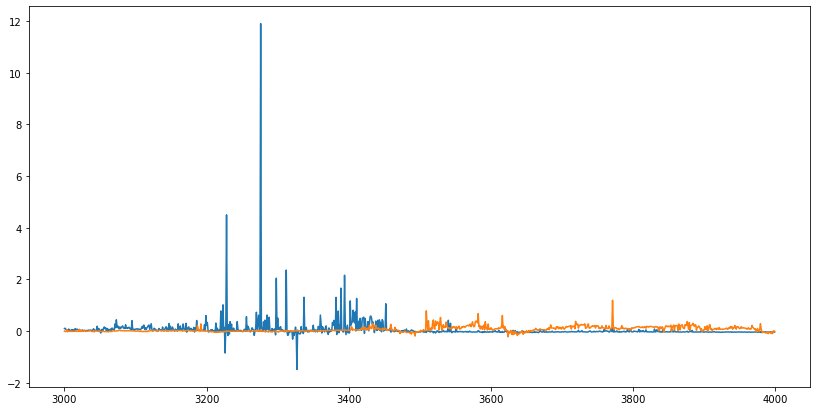

In [12]:
plt.figure(figsize=(14,7))
plt.plot(principalDf['PC1'][3000:4000])
plt.plot(principalDf['PC2'][3000:4000])

In [20]:
pca.explained_variance_ratio_

array([0.36016637, 0.16643133, 0.13146125, 0.10535605, 0.07447364])

(-1.0, 1.0)

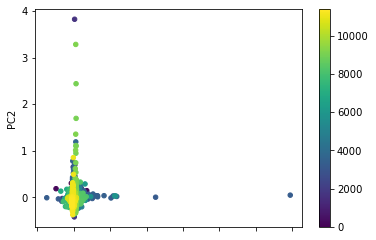

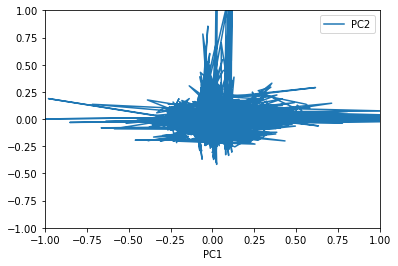

In [13]:
fig = principalDf.plot.scatter(x='PC1', y='PC2',c=principalDf.index, colormap='viridis')
fig= principalDf.plot(x='PC1', y='PC2')
fig.set_xlim([-1,1])
fig.set_ylim([-1,1])

In [14]:
plt.figure(figsize=(7,7))
for k,d in principalDf:
    plt.scatter(k,d)
#plt.scatter(principalDf['PC1'][0:10],principalDf['PC2'][0:10])
#plt.plot(principalDf['PC2'][3000:4000])

ValueError: too many values to unpack (expected 2)

<Figure size 504x504 with 0 Axes>

In [ ]:
k,d=principalDf

In [ ]:
d

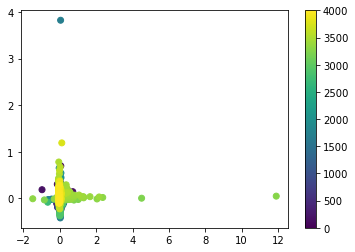

In [15]:
plt.scatter(principalDf['PC1'][0:4000],principalDf['PC2'][0:4000],c=np.arange(0,4000), vmin=0, vmax=4000)
plt.colorbar()
# ax_lim=0.2
# plt.xlim(-ax_lim,ax_lim)
# plt.ylim(-ax_lim,ax_lim)

(-0.2, 0.2)

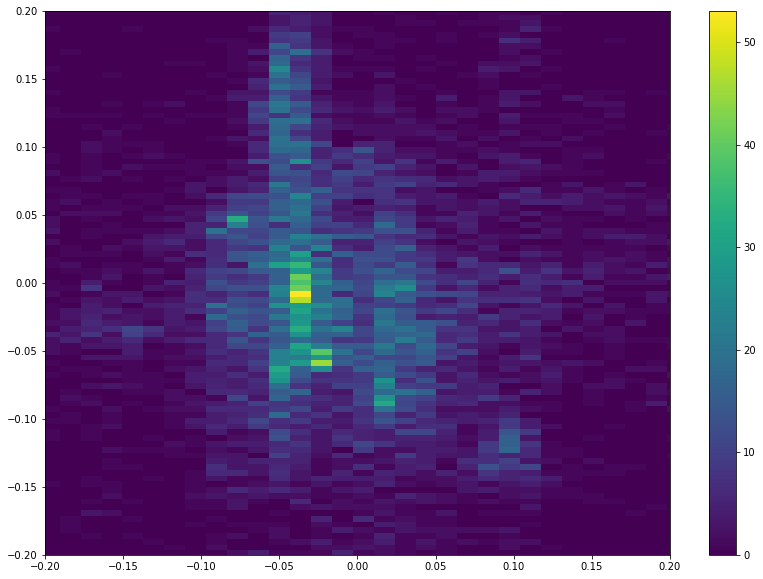

In [16]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

(-0.5, 0.5)

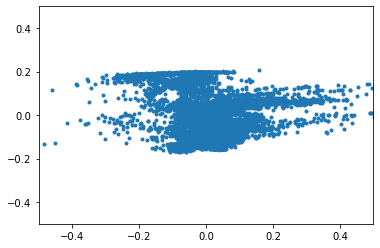

In [17]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

(-0.5, 0.5)

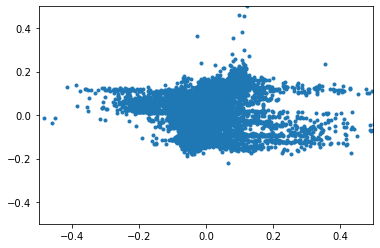

In [18]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [99]:
import re
dir=re.split('-channel',re.split('/',input_filename)[-1])[0]

In [102]:
dir+'_skeleton_X_coords.csv'

'2020-06-05_16-46-41_worm1_skeleton_X_coords.csv'

In [12]:
input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/'

In [15]:
output_path=os.path.join(input_filename, 'skeletons')


In [16]:
output_path

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeletons'